# Setup

In [ ]:
!pip install -q datasets transformers evaluate accelerate
!pip install -q "ray[tune]" scipy sklearn torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 13.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 MB 25.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generati

In [ ]:
!pip -q install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 23.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.2/802.2 kB 28.0 MB/s eta 0:00:00


In [ ]:
import os, sys
import pickle
from time import gmtime, strftime
from tqdm.notebook import tqdm  # Progress bar

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy as sp

import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from lightning.pytorch.utilities import CombinedLoader
from sklearn.metrics import f1_score, classification_report

from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, AutoModel, AutoConfig
from transformers import DebertaV2Config, DebertaV2Model, DebertaV2PreTrainedModel
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer
from transformers import get_scheduler


In [ ]:
'''Set-up GPU for use'''

gpu_avail = torch.cuda.is_available()
print(f"Is the GPU available? {gpu_avail}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

# GPU operations have a separate seed
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Some operations on a GPU are implemented stochastic for efficiency
# Ensure that all operations are deterministic on GPU for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Is the GPU available? True
Device cuda


# Prepare Datasets

In [ ]:
#ucc_train_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/ucc_train_no_scores.csv'
ucc_test_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/ucc_test_no_scores.csv'
ucc_train_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/ucc_train_confident_no_scores.csv'
#ucc_test_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/ucc_test_confident_no_sarcasm.csv'

reddit_train_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/reddit_train_balanced.csv'
reddit_test_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/reddit_test_balanced.csv'

In [ ]:
# Get max length of text in UCC dataset
df = pd.read_csv(ucc_train_filename)
text_column = df['comment']
max_length_ucc = np.max(np.array([len(comment) for comment in text_column]))
print('UCC max length: ', max_length_ucc)

# Get max length of text in reddit dataset
df = pd.read_csv(reddit_train_filename)
text_column = df['text']
max_length_reddit = np.max(np.array([len(text) for text in text_column]))
print('Reddit max length: ', max_length_reddit)

UCC max length:  349
Reddit max length:  36239


In [ ]:
less_100 = 0
less_1000 = 0
less_2000 = 0
less_5000 = 0
less_10000 = 0
less_20000 = 0
greater_20000 = 0
for i in df.index:
    if len(df['text'][i]) < 100:
        less_100 += 1
    elif len(df['text'][i]) < 1000:
        less_1000 += 1
    elif len(df['text'][i]) < 2000:
        less_2000 += 1
    elif len(df['text'][i]) < 5000:
        less_5000 += 1
    elif len(df['text'][i]) < 10000:
        less_10000 += 1
    elif len(df['text'][i]) < 20000:
        less_20000 += 1
    else:
        greater_20000 += 1

print(less_100)
print(less_1000)
print(less_2000)
print(less_5000)
print(less_10000)
print(less_20000)
print(greater_20000)

32
613
498
805
269
57
7


In [ ]:
max_length = 1000

# Tokenize data

In [ ]:
def preprocess_ucc(example):
    '''Method for preprocessing the UCC dataset'''

    # Gather list of positive labels
    all_labels = []
    for class_ in classes:
        if example[class_] == 1:
            all_labels.append(class_)

    # Convert labels to a vector of binary values
    labels = [0.0 for i in range(len(classes))]
    for label in all_labels:
        label_id = class2id[label]
        labels[label_id] = 1

    example = tokenizer(example['comment'], padding='max_length', truncation=True)
    example['labels'] = labels

    return example

def preprocess_reddit(example):

    if example['labels'] == 'abuse':
        example['labels'] = 1.0
    elif example['labels'] == 'non_abuse':
        example['labels'] = 0.0
    else:
        sys.error(1)

    example = tokenizer(example['text'], padding='max_length', truncation=True)
    return example


ucc = load_dataset('csv', data_files={'train': ucc_train_filename, 'test': ucc_test_filename})
reddit = load_dataset('csv', data_files={'train': reddit_train_filename, 'test': reddit_test_filename})

# Dicts for the UCC dataset to convert between class name and class numerical id
classes = [class_ for class_ in list(ucc['train'].features)[1:] if class_]
class2id = {class_:id for id, class_ in enumerate(classes)}
id2class = {id:class_ for class_, id in class2id.items()}
# Dicts for the Reddit dataset to convert between class name and binary label
class2binary = {'abuse': 1, 'non_abuse': 0}
binary2class = {1:'abuse', 0:'non_abuse'}

# Tokenize Data
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small', model_max_length=max_length, use_fast=False)
tokenized_ucc = ucc.map(preprocess_ucc)
tokenized_reddit = reddit.map(preprocess_reddit)

# Delete class columns from reddit dataset now that we represent the labels as vecs
tokenized_ucc = tokenized_ucc.remove_columns(classes)


Map:   0%|          | 0/882 [00:00<?, ? examples/s]

Map:   0%|          | 0/4425 [00:00<?, ? examples/s]

Map:   0%|          | 0/2281 [00:00<?, ? examples/s]

Map:   0%|          | 0/410 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_ucc, '\n')
print(tokenized_reddit)

DatasetDict({
    train: Dataset({
        features: ['comment', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 882
    })
    test: Dataset({
        features: ['comment', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4425
    })
}) 

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2281
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 410
    })
})


### Finetuning model in native pytorch:

In [ ]:
# To prepare the tokenized datasets for training in native pytorch, do the following:

# The model does not accept raw text as an input. Remove the 'comment' and 'text' columns:
tokenized_ucc = tokenized_ucc.remove_columns(['comment'])
tokenized_reddit = tokenized_reddit.remove_columns(['text'])

# Set the format of the dataset to return PyTorch tensors instead of lists:
tokenized_ucc.set_format('torch')
tokenized_reddit.set_format('torch')

# Split the tokenized data into train, test, and validation
ucc_train_dataset = tokenized_ucc['train'].shuffle(seed=6)
ucc_eval_dataset = tokenized_ucc['test'].shuffle(seed=6)
reddit_train_dataset = tokenized_reddit['train'].shuffle(seed=6)
reddit_eval_dataset = tokenized_reddit['test'].shuffle(seed=6)

# Note: pytorch requires the label column to be named 'labels'. Change if needed.

# Define Model Class

In [ ]:
class MTLTextClassification(nn.Module):
    def __init__(self, llm, activation=nn.LeakyReLU()):
        super(MTLTextClassification, self).__init__()

        self.llm = llm
        self.activation = activation

        self.feature_extractor = torch.nn.Sequential(
            nn.Dropout(p=0.2),
            torch.nn.Linear(768, 64),
            torch.nn.LeakyReLU(),
        )

        self.reddit_out = torch.nn.Linear(64, 1)
        self.ucc_out = torch.nn.Linear(64, 5)

    def forward(self, input_ids, token_type_ids, attention_mask, taskid):
        # Get embedding from the LLM we are tuning. Use last hidden state of embedding for classification tasks.
        x = self.llm(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask)
        x = x["last_hidden_state"][:,0,:]

        # Extract shared features for both tasks
        features = self.feature_extractor(x)

        # Branch on task
        if taskid == 1:
            logits = self.ucc_out(features)     # Get output for task 1: UCC classification (BCEWithLogitsLoss)
        elif taskid == 2:
            logits = self.reddit_out(features)  # Get output for task 2: Abuse/Non-abuse classification (BCEWithLogitsLoss)

        return logits


# Analyzing the Trained Models

In [ ]:
# All trained models
#llm_name = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_Apr29_01_05_21.tar'    # eta=1.0 (equal) and standard ucc dataset
#llm_name = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_eta_40-60.tar'         # eta=0.4 and standard ucc dataset
#llm_name = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_eta_60-40.tar'         # eta=0.6 and standard ucc dataset
#llm_name = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_confident.tar'         # default eta and confident ucc dataset

#model_name = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_Apr29_01_05_21.tar'  # eta=1.0 (equal) and standard ucc dataset
#model_name = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_eta_40-60.tar'       # eta=0.4 and standard ucc dataset
#model_name = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_eta_60-40.tar'       # eta=0.6 and standard ucc dataset
#model_name = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_confident.tar'       # default eta and confident ucc dataset

In [ ]:
def load_saved_model(model_file, llm_file, train_results_file, test_results_file):
    # load LLM
    llm_state_dict = torch.load(llm_file)
    saved_llm = AutoModel.from_pretrained('microsoft/deberta-v3-small')
    saved_llm.load_state_dict(llm_state_dict)
    # load model
    state_dict = torch.load(model_file)
    saved_mtl_model = MTLTextClassification(llm=saved_llm)
    saved_mtl_model.load_state_dict(state_dict)

    # load training and testing results
    with open(train_results_file, 'rb') as handle:
        train_results = pickle.load(handle)
    with open(test_results_file, 'rb') as handle:
        test_results = pickle.load(handle)

    return saved_mtl_model, saved_llm, train_results, test_results

## MTL: eta=1.0 and standard UCC

In [ ]:
# Load Model
llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_Apr29_01_05_21.tar'
model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_Apr29_01_05_21.tar'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/results_Apr29_01_05_21.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/test_results_Apr29_01_05_21.pickle'
mtl_model, llm, train_results, test_results = load_saved_model(model_file, llm_file, train_file, test_file)

In [ ]:
test_results.keys()
all_losses = test_results['loss_per_batch']

In [ ]:
print(test_results['loss_per_batch'])
print('\n', test_results['reddit_losses'])
print('\n', test_results['ucc_losses'])
print('\n', test_results['total_accs'])
print('\n', test_results['reddit_accs'])
print('\n', test_results['ucc_accs'])

[0.837800920009613, 0.6500576138496399, 1.004942536354065, 0.6488524675369263, 0.7986166477203369, 0.8020914196968079, 0.9710840582847595, 1.1314635276794434, 0.8325124979019165, 2.5240447521209717, 1.5739046335220337, 1.0189716815948486, 0.924556314945221, 1.0891063213348389, 0.7260642051696777, 0.7055050134658813, 0.9607154726982117, 0.6164498329162598, 0.7415503859519958, 0.9768580198287964, 1.0143699645996094, 2.0642638206481934, 0.8983373045921326, 0.7795422077178955, 1.0416215658187866, 0.9439018964767456, 0.9226004481315613, 1.3221228122711182, 0.7696347236633301, 0.8293351531028748, 1.303263545036316, 1.0784950256347656, 0.611971378326416, 0.8926021456718445, 0.9320943355560303, 1.149741768836975, 0.7773311138153076, 0.8053609728813171, 0.8810107111930847, 0.8616552352905273, 1.3982763290405273, 0.7324250340461731, 0.5006265640258789, 0.7998397350311279, 0.8680815696716309, 0.5504544377326965, 0.9807568192481995, 2.5392658710479736, 2.8129003047943115, 1.0111851692199707, 0.782

In [ ]:
# Convert tensors to scalars
test_results['loss_per_batch_std'] = np.std(test_results['loss_per_batch'])
test_results['reddit_losses_std'] = np.std(test_results['reddit_losses'])
test_results['ucc_losses_std'] = np.std(test_results['ucc_losses'])
test_results['loss_per_batch'] = np.mean(test_results['loss_per_batch'])
test_results['reddit_losses'] = np.mean(test_results['reddit_losses'])
test_results['ucc_losses'] = np.mean(test_results['ucc_losses'])
test_results['total_accs'] = test_results['total_accs'][0].item()
test_results['ucc_accs'] = test_results['ucc_accs'][0].item()
test_results['reddit_accs'] = test_results['reddit_accs'][0].item()

In [ ]:
print('Avg Loss across batches: ', test_results['loss_per_batch'], '\t\t+/-', test_results['loss_per_batch_std'])
print('Avg UCC Loss across batches: ', test_results['ucc_losses'], '\t+/-', test_results['ucc_losses_std'])
print('Avg Reddit Loss across batches: ', test_results['reddit_losses'], '\t+/-', test_results['reddit_losses_std'])
print('Accuracy for Both tasks: ', test_results['total_accs'])
print('Accuracy for UCC Test set: ', test_results['ucc_accs'])
print('Accuracy for Reddit Test set: ', test_results['reddit_accs'])

Avg Loss across batches:  1.0826799208609608 		+/- 0.5925600113905866
Avg UCC Loss across batches:  0.8666079526509696 	+/- 0.182305174883667
Avg Reddit Loss across batches:  0.21607196684580499 	+/- 0.5625662708150606
Accuracy for Both tasks:  0.685348391532898
Accuracy for UCC Test set:  0.6310056447982788
Accuracy for Reddit Test set:  0.9570621252059937


## MTL: eta=0.4 and standard UCC

In [ ]:
# Load Model
llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_eta_40-60.tar'         # default eta and confident ucc dataset
model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_eta_40-60'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/results_eta_40_60.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/test_results_eta_40_60.pickle'
mtl_model, llm, train_results, test_results = load_saved_model(model_file, llm_file, train_file, test_file)

In [ ]:
print(test_results['loss_per_batch'])
print('\n', test_results['reddit_losses'])
print('\n', test_results['ucc_losses'])
print('\n', test_results['total_accs'])
print('\n', test_results['reddit_accs'])
print('\n', test_results['ucc_accs'])

[0.2515820264816284, 0.30462223291397095, 0.28352081775665283, 0.21842609345912933, 0.3318033516407013, 0.2767980396747589, 0.2952428460121155, 0.2239668071269989, 0.2921292185783386, 0.2543107271194458, 0.24974782764911652, 0.2965087890625, 0.21710573136806488, 0.22875642776489258, 0.3278528153896332, 0.30622926354408264, 0.27040010690689087, 0.2173270434141159, 0.23256848752498627, 0.2965920865535736, 1.3298357725143433, 0.6180810928344727, 0.21082495152950287, 0.8387880325317383, 0.1869775950908661, 0.24864521622657776, 0.24311520159244537, 0.9512433409690857, 1.1774836778640747, 0.24389034509658813, 0.222080796957016, 1.3060250282287598, 0.27160751819610596, 0.24528896808624268, 0.23841649293899536, 0.8463500142097473, 0.1971748173236847, 0.25619786977767944, 0.23391307890415192, 0.29639774560928345, 0.23593220114707947, 0.22616618871688843, 0.21749480068683624, 0.2895803451538086, 0.29905790090560913, 0.24386566877365112, 0.19018465280532837, 0.3369552195072174, 0.2652629315853119

In [ ]:
# Convert tensors to scalars
test_results['loss_per_batch_std'] = np.std(test_results['loss_per_batch'])
test_results['reddit_losses_std'] = np.std(test_results['reddit_losses'])
test_results['ucc_losses_std'] = np.std(test_results['ucc_losses'])
test_results['loss_per_batch'] = np.mean(test_results['loss_per_batch'])
test_results['reddit_losses'] = np.mean(test_results['reddit_losses'])
test_results['ucc_losses'] = np.mean(test_results['ucc_losses'])
test_results['total_accs'] = test_results['total_accs'][0].item()
test_results['ucc_accs'] = test_results['ucc_accs'][0].item()
test_results['reddit_accs'] = test_results['reddit_accs'][0].item()

In [ ]:
print('Avg Loss across batches: ', test_results['loss_per_batch'], '\t\t+/-', test_results['loss_per_batch_std'])
print('Avg UCC Loss across batches: ', test_results['ucc_losses'], '\t+/-', test_results['ucc_losses_std'])
print('Avg Reddit Loss across batches: ', test_results['reddit_losses'], '\t+/-', test_results['reddit_losses_std'])
print('Accuracy for Both tasks: ', test_results['total_accs'])
print('Accuracy for UCC Test set: ', test_results['ucc_accs'])
print('Accuracy for Reddit Test set: ', test_results['reddit_accs'])

Avg Loss across batches:  0.36501269331900194 		+/- 0.29240814089572514
Avg UCC Loss across batches:  0.6350070477716537 	+/- 0.10368945000685952
Avg Reddit Loss across batches:  0.18501644095598593 	+/- 0.480509240216424
Accuracy for Both tasks:  0.6897552013397217
Accuracy for UCC Test set:  0.636926531791687
Accuracy for Reddit Test set:  0.9538983106613159


## MTL: eta=0.6 and standard UCC

In [ ]:
# Load Model
llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_eta_60-40.tar'         # default eta and confident ucc dataset
model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_eta_60-40'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/results_eta_60_40.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/test_results_eta_60_40.pickle'
mtl_model, llm, train_results, test_results = load_saved_model(model_file, llm_file, train_file, test_file)

In [ ]:
print(test_results['loss_per_batch'])
print('\n', test_results['reddit_losses'])
print('\n', test_results['ucc_losses'])
print('\n', test_results['total_accs'])
print('\n', test_results['reddit_accs'])
print('\n', test_results['ucc_accs'])

[0.4106024503707886, 0.49444612860679626, 0.38467937707901, 0.3995342552661896, 0.3271733820438385, 0.44665253162384033, 0.3055095672607422, 0.4211154282093048, 0.30494898557662964, 0.32770970463752747, 0.3478173315525055, 0.32300058007240295, 0.3142624795436859, 0.3738752007484436, 0.39695730805397034, 0.48808804154396057, 0.34089162945747375, 0.34663426876068115, 0.8744474649429321, 0.36360102891921997, 0.341406911611557, 0.36786913871765137, 0.342995822429657, 0.3295048773288727, 0.3310932517051697, 0.3454454839229584, 0.28522011637687683, 0.36552947759628296, 0.3554512560367584, 0.3553358316421509, 0.4223974645137787, 0.37750160694122314, 0.39545413851737976, 0.35474270582199097, 0.3680720627307892, 0.34129196405410767, 0.30801883339881897, 0.44520625472068787, 0.40237873792648315, 0.3265219032764435, 0.35196879506111145, 0.3018516004085541, 0.3571587800979614, 0.3849429786205292, 0.897473931312561, 0.26679104566574097, 0.3438495397567749, 0.7515950202941895, 0.3187498152256012, 0.

In [ ]:
# Convert tensors to scalars
test_results['loss_per_batch_std'] = np.std(test_results['loss_per_batch'])
test_results['reddit_losses_std'] = np.std(test_results['reddit_losses'])
test_results['ucc_losses_std'] = np.std(test_results['ucc_losses'])
test_results['loss_per_batch'] = np.mean(test_results['loss_per_batch'])
test_results['reddit_losses'] = np.mean(test_results['reddit_losses'])
test_results['ucc_losses'] = np.mean(test_results['ucc_losses'])
test_results['total_accs'] = test_results['total_accs'][0].item()
test_results['ucc_accs'] = test_results['ucc_accs'][0].item()
test_results['reddit_accs'] = test_results['reddit_accs'][0].item()

In [ ]:
print('Avg Loss across batches: ', test_results['loss_per_batch'], '\t\t+/-', test_results['loss_per_batch_std'])
print('Avg UCC Loss across batches: ', test_results['ucc_losses'], '\t+/-', test_results['ucc_losses_std'])
print('Avg Reddit Loss across batches: ', test_results['reddit_losses'], '\t+/-', test_results['reddit_losses_std'])
print('Accuracy for Both tasks: ', test_results['total_accs'])
print('Accuracy for UCC Test set: ', test_results['ucc_accs'])
print('Accuracy for Reddit Test set: ', test_results['reddit_accs'])

Avg Loss across batches:  0.4043862496745834 		+/- 0.15100246562764072
Avg UCC Loss across batches:  0.5825856280089933 	+/- 0.07621342959119402
Avg Reddit Loss across batches:  0.13708714689639193 	+/- 0.35657265401553706
Accuracy for Both tasks:  0.7474576234817505
Accuracy for UCC Test set:  0.7050847411155701
Accuracy for Reddit Test set:  0.9593220353126526


## MTL: eta=1.0 and Confident UCC

In [ ]:
# Load Model
llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_confident.tar'         # default eta and confident ucc dataset
model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_confident.tar'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/results_confident.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/test_results_confident.pickle'
mtl_model, llm, train_results, test_results = load_saved_model(model_file, llm_file, train_file, test_file)

In [ ]:
print(test_results['loss_per_batch'])
print('\n', test_results['reddit_losses'])
print('\n', test_results['ucc_losses'])
print('\n', test_results['total_accs'])
print('\n', test_results['reddit_accs'])
print('\n', test_results['ucc_accs'])

[0.4647546112537384, 0.5725728273391724, 1.291042447090149, 0.7057394981384277, 1.9828407764434814, 1.0631129741668701, 0.9865999817848206, 0.4756107032299042, 1.538727045059204, 0.7137460708618164, 0.6907265782356262, 0.7800514101982117, 1.013400912284851, 0.6180505752563477, 0.5777503252029419, 0.7092309594154358, 1.0788737535476685, 1.171774983406067, 0.649541437625885, 0.9185858964920044, 0.5127812623977661, 0.9554517865180969, 0.6204013228416443, 2.4131197929382324, 0.44444000720977783, 0.7769825458526611, 0.817976713180542, 1.0406690835952759, 0.9006519913673401, 1.0141414403915405, 0.7822259664535522, 0.4080352187156677, 0.5378401279449463, 1.0519590377807617, 0.6324964761734009, 0.7427458763122559, 0.7776870727539062, 0.3864499032497406, 2.7903521060943604, 0.9070756435394287, 1.328558087348938, 0.8419956564903259, 0.7373931407928467, 0.6379733681678772, 0.7852169275283813, 0.9279129505157471, 0.9301953315734863, 0.7032673954963684, 0.6666738390922546, 1.6994304656982422, 0.536

In [ ]:
# Convert tensors to scalars
test_results['loss_per_batch_std'] = np.std(test_results['loss_per_batch'])
test_results['reddit_losses_std'] = np.std(test_results['reddit_losses'])
test_results['ucc_losses_std'] = np.std(test_results['ucc_losses'])
test_results['loss_per_batch'] = np.mean(test_results['loss_per_batch'])
test_results['reddit_losses'] = np.mean(test_results['reddit_losses'])
test_results['ucc_losses'] = np.mean(test_results['ucc_losses'])
test_results['total_accs'] = test_results['total_accs'][0].item()
test_results['ucc_accs'] = test_results['ucc_accs'][0].item()
test_results['reddit_accs'] = test_results['reddit_accs'][0].item()

In [ ]:
print('Avg Loss across batches: ', test_results['loss_per_batch'], '\t\t+/-', test_results['loss_per_batch_std'])
print('Avg UCC Loss across batches: ', test_results['ucc_losses'], '\t+/-', test_results['ucc_losses_std'])
print('Avg Reddit Loss across batches: ', test_results['reddit_losses'], '\t+/-', test_results['reddit_losses_std'])
print('Accuracy for Both tasks: ', test_results['total_accs'])
print('Accuracy for UCC Test set: ', test_results['ucc_accs'])
print('Accuracy for Reddit Test set: ', test_results['reddit_accs'])

Avg Loss across batches:  0.8481156836518751 		+/- 0.40880452623429525
Avg UCC Loss across batches:  0.7215279801105096 	+/- 0.21135283300433685
Avg Reddit Loss across batches:  0.12658770243252787 	+/- 0.3513349806793583
Accuracy for Both tasks:  0.7543503046035767
Accuracy for UCC Test set:  0.7132655382156372
Accuracy for Reddit Test set:  0.9597740173339844


# STL UCC

In [ ]:
def load_results(train_results_file, test_results_file):
    # load training and testing results
    with open(train_results_file, 'rb') as handle:
        train_results = pickle.load(handle)
    with open(test_results_file, 'rb') as handle:
        test_results = pickle.load(handle)

    return train_results, test_results

In [ ]:
# Load Model
#llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_eta_40-60.tar'         # default eta and confident ucc dataset
#model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_eta_40-60'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/ucc_stl_train_results.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/ucc_stl_test_results.pickle'
train_results, test_results = load_results(train_file, test_file)

In [ ]:
print(test_results['Loss'])
print('\n', test_results['Accuracy'])

[[0.7617624402046204, 0.5857369303703308, 0.6096445918083191, 0.8974941372871399, 0.726025402545929, 0.5954607725143433, 0.5141767263412476, 0.6472651958465576, 0.8744198679924011, 0.6528841257095337, 0.5281224846839905, 0.5368625521659851, 0.6032954454421997, 0.767272412776947, 0.588930070400238, 0.8947791457176208, 0.6772117614746094, 0.5720926523208618, 0.7823705077171326, 0.5578999519348145, 0.4938938319683075, 0.9363555312156677, 0.7398008108139038, 0.5979151129722595, 0.555163562297821, 0.779102087020874, 0.6528010368347168, 0.5910881161689758, 0.8282127380371094, 0.6977710723876953, 0.5201988220214844, 0.737060010433197, 0.753470242023468, 0.5617332458496094, 0.6747739911079407, 0.7238931655883789, 0.5002960562705994, 0.6879374384880066, 0.7267091274261475, 0.3771169185638428, 0.47025609016418457, 0.6771900653839111, 0.8274480700492859, 0.6717905402183533, 0.4974219799041748, 0.7827648520469666, 0.6428649425506592, 0.6825558543205261, 1.1396769285202026, 0.7148769497871399, 0.59

In [ ]:
# Convert tensors to scalars
test_results['Accuracy'] = test_results['Accuracy'].item()
test_results['Loss'] = test_results['Loss'][0]

In [ ]:
print(test_results['Loss'])
print('\n', test_results['Accuracy'])

[0.7617624402046204, 0.5857369303703308, 0.6096445918083191, 0.8974941372871399, 0.726025402545929, 0.5954607725143433, 0.5141767263412476, 0.6472651958465576, 0.8744198679924011, 0.6528841257095337, 0.5281224846839905, 0.5368625521659851, 0.6032954454421997, 0.767272412776947, 0.588930070400238, 0.8947791457176208, 0.6772117614746094, 0.5720926523208618, 0.7823705077171326, 0.5578999519348145, 0.4938938319683075, 0.9363555312156677, 0.7398008108139038, 0.5979151129722595, 0.555163562297821, 0.779102087020874, 0.6528010368347168, 0.5910881161689758, 0.8282127380371094, 0.6977710723876953, 0.5201988220214844, 0.737060010433197, 0.753470242023468, 0.5617332458496094, 0.6747739911079407, 0.7238931655883789, 0.5002960562705994, 0.6879374384880066, 0.7267091274261475, 0.3771169185638428, 0.47025609016418457, 0.6771900653839111, 0.8274480700492859, 0.6717905402183533, 0.4974219799041748, 0.7827648520469666, 0.6428649425506592, 0.6825558543205261, 1.1396769285202026, 0.7148769497871399, 0.591

In [ ]:
std_dev = np.std(test_results['Loss'])
avg_loss = np.mean(test_results['Loss'])

In [ ]:
print('Avg Loss across batches: ', avg_loss, '\t+/-  ', std_dev)
print('UCC Accuracy: ', test_results['Accuracy'])

Avg Loss across batches:  0.6521444635393389 	+/-   0.12405238292890061
UCC Accuracy:  0.7125875353813171


# STL Reddit

In [ ]:
# Load Model
#llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_eta_40-60.tar'         # default eta and confident ucc dataset
#model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_eta_40-60'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/reddit_stl_train_results.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/reddit_stl_test_results.pickle'
train_results, test_results = load_results(train_file, test_file)

In [ ]:
print(test_results['Loss'])
print('\n', test_results['Accuracy'])

[[0.0022627608850598335, 1.3653026819229126, 0.0017041885294020176, 1.4201394319534302, 0.002832234837114811, 0.002277981024235487, 0.0023861820809543133, 0.5681189894676208, 1.4310870170593262, 1.4044513702392578, 0.0170191191136837, 1.4595136642456055, 0.0022306195460259914, 0.0023828705307096243, 0.10712974518537521, 0.002165463287383318, 0.002220327500253916, 0.0027341332752257586, 0.5504810810089111, 0.0029590122867375612, 0.002706478349864483, 0.0031167708802968264, 0.0022015217691659927, 1.3916493654251099, 0.017410479485988617, 0.002852398669347167, 0.022021811455488205, 0.00303144589997828, 0.0029942442197352648, 0.002172626554965973, 0.0022992254234850407, 1.4004793167114258, 0.002318950369954109, 0.037163250148296356, 0.0027529364451766014, 0.0016284307930618525, 0.0030082883313298225, 0.008950408548116684, 0.002736220136284828, 0.0028414600528776646, 0.0020427138078957796, 0.0025428305380046368, 0.00168781285174191, 0.006919213104993105, 0.02625717781484127, 0.0016976168844

In [ ]:
# Convert tensors to scalars
test_results['Accuracy'] = test_results['Accuracy'].item()
test_results['Loss'] = test_results['Loss'][0]

In [ ]:
print(test_results['Loss'])
print('\n', test_results['Accuracy'])

[0.0022627608850598335, 1.3653026819229126, 0.0017041885294020176, 1.4201394319534302, 0.002832234837114811, 0.002277981024235487, 0.0023861820809543133, 0.5681189894676208, 1.4310870170593262, 1.4044513702392578, 0.0170191191136837, 1.4595136642456055, 0.0022306195460259914, 0.0023828705307096243, 0.10712974518537521, 0.002165463287383318, 0.002220327500253916, 0.0027341332752257586, 0.5504810810089111, 0.0029590122867375612, 0.002706478349864483, 0.0031167708802968264, 0.0022015217691659927, 1.3916493654251099, 0.017410479485988617, 0.002852398669347167, 0.022021811455488205, 0.00303144589997828, 0.0029942442197352648, 0.002172626554965973, 0.0022992254234850407, 1.4004793167114258, 0.002318950369954109, 0.037163250148296356, 0.0027529364451766014, 0.0016284307930618525, 0.0030082883313298225, 0.008950408548116684, 0.002736220136284828, 0.0028414600528776646, 0.0020427138078957796, 0.0025428305380046368, 0.00168781285174191, 0.006919213104993105, 0.02625717781484127, 0.00169761688448

In [ ]:
std_dev = np.std(test_results['Loss'])
avg_loss = np.mean(test_results['Loss'])

In [ ]:
print('Avg Loss across batches: ', avg_loss, '\t+/-  ', std_dev)
print('UCC Accuracy: ', test_results['Accuracy'])

Avg Loss across batches:  0.17108089300844528 	+/-   0.42794846560037114
UCC Accuracy:  0.9634146094322205


In [ ]:
train_results.keys()


dict_keys(['Loss', 'Accuracy'])

In [ ]:
print(train_results['Loss'])
print('\n', train_results['Accuracy'])

[[0.6498017311096191, 0.687649667263031, 0.6373634338378906, 0.7000095844268799, 0.6857584118843079, 0.8119693994522095, 0.7475844621658325, 0.6807709336280823, 0.6722762584686279, 0.70466148853302, 0.7079836130142212, 0.7411836385726929, 0.651775062084198, 0.7247179746627808, 0.7426877021789551, 0.6682299971580505, 0.7637718915939331, 0.6938779354095459, 0.6312646865844727, 0.6610472202301025, 0.6663303971290588, 0.7070814371109009, 0.7433936595916748, 0.6887022256851196, 0.6580103039741516, 0.5920882225036621, 0.7883275151252747, 0.6641754508018494, 0.6476806402206421, 0.6333605051040649, 0.6074350476264954, 0.6533716320991516, 0.7096661329269409, 0.5265636444091797, 0.46736806631088257, 0.3660549521446228, 0.3439991772174835, 0.2461530864238739, 0.8595673441886902, 1.0674538612365723, 1.0184210538864136, 0.331582635641098, 0.7492717504501343, 0.43538564443588257, 0.1753745973110199, 0.7343425750732422, 0.5060766935348511, 0.7084637880325317, 0.7456738948822021, 0.5870519876480103, 0

In [ ]:
# Convert tensors to scalars
epoch_accs = []
for acc in train_results['Accuracy']:
    epoch_accs.append(acc.item())
train_results['Accuracy'] = epoch_accs

In [ ]:
print(train_results['Loss'])
print('\n', train_results['Accuracy'])

[[0.6498017311096191, 0.687649667263031, 0.6373634338378906, 0.7000095844268799, 0.6857584118843079, 0.8119693994522095, 0.7475844621658325, 0.6807709336280823, 0.6722762584686279, 0.70466148853302, 0.7079836130142212, 0.7411836385726929, 0.651775062084198, 0.7247179746627808, 0.7426877021789551, 0.6682299971580505, 0.7637718915939331, 0.6938779354095459, 0.6312646865844727, 0.6610472202301025, 0.6663303971290588, 0.7070814371109009, 0.7433936595916748, 0.6887022256851196, 0.6580103039741516, 0.5920882225036621, 0.7883275151252747, 0.6641754508018494, 0.6476806402206421, 0.6333605051040649, 0.6074350476264954, 0.6533716320991516, 0.7096661329269409, 0.5265636444091797, 0.46736806631088257, 0.3660549521446228, 0.3439991772174835, 0.2461530864238739, 0.8595673441886902, 1.0674538612365723, 1.0184210538864136, 0.331582635641098, 0.7492717504501343, 0.43538564443588257, 0.1753745973110199, 0.7343425750732422, 0.5060766935348511, 0.7084637880325317, 0.7456738948822021, 0.5870519876480103, 0

In [ ]:
avg_loss = [np.mean(epoch_list) for epoch_list in train_results['Loss']]

In [ ]:
print('Avg Loss per epoch: ', avg_loss)
print('Reddit Accuracy per epoch: ', train_results['Accuracy'])

Avg Loss per epoch:  [0.3102371198192056, 0.1545031421765646, 0.07590396811324457, 0.04020011243585745, 0.02149571044551577]
Reddit Accuracy per epoch:  [0.8746163845062256, 0.9522139430046082, 0.9758877754211426, 0.9903551340103149, 0.9956159591674805]


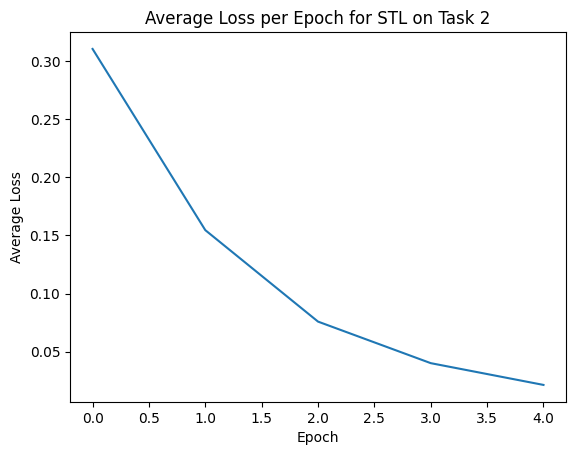

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), avg_loss, label='Loss')
plt.title('Average Loss per Epoch for STL on Task 2')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.show()

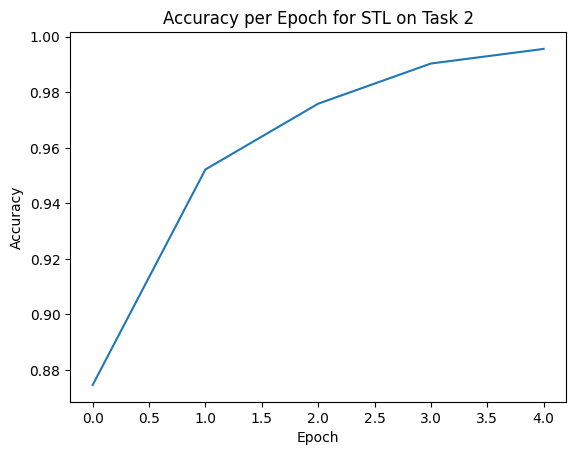

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), train_results['Accuracy'], label='Accuracy')
plt.title('Accuracy per Epoch for STL on Task 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()